# Pretrained baselines without SAM — ResNet18, ViT‑B/16
- Fine‑tuning schedule, LLRD for ViT head, recall‑first evaluation.

In [1]:
# Clean imports + path setup
import sys
from pathlib import Path
import warnings

# tqdm: prefer notebook widgets, fallback to text
try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Resolve project root (directory containing `src/`)
proj_root = Path.cwd()
for _ in range(5):
    if (proj_root / "src").exists():
        break
    proj_root = proj_root.parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))
print("sys.path[0] =", sys.path[0])

# Weights path
weights_path = proj_root / "notebooks" / "weights" / "ViT-B_16.npz"
print("weights:", weights_path)

# Project imports
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch, build_vit_pretrained,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch, time
set_seed(42)
DEVICE = get_device(); DEVICE


sys.path[0] = /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project
weights: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project/notebooks/weights/ViT-B_16.npz


device(type='mps')

In [ ]:
# === Paths/config ===
DATASET_DIR = Path("../Data/chest_xray")  # <--- EDIT THIS IF NEEDED

# Use the SAME split as scratch for fairness
data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,
    batch_size=32,
    num_workers=0,
    pin_memory=True,
    use_stratified_val=True,
    val_ratio=0.20,          # <<-- keep this identical across all notebooks
    gray_to_rgb=True,
    compute_norm_stats=False,
    balance_sampler=True     # match whatever you used in scratch
)

pretrain_cfg = TrainCfg(
    epochs=20, patience=5, monitor="va_auroc",
    base_lr=1e-4, weight_decay=1e-4,  # good defaults for pretrained fine-tuning
    clip_grad_norm=1.0, use_amp=False,
    use_sam=False, sam_rho=0.05,      # SAM OFF in this notebook
    use_cosine=True, warmup_epochs=2, min_lr_mult=0.05,
    target_recall=0.95,
    llrd=True, head_lr_mult=10.0,     # faster head for ViT
    vit_npz_path=weights_path         # set this to notebooks/weights/ViT-B_16.npz or None if using timm
)

train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
arr = np.array(info["train_counts"], dtype=float)
w = arr.sum() / (len(arr) * (arr + 1e-9))
class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4447 785 624


[ResNet18-pretrained] epoch 01/20  tr_loss=0.7055  val_loss=0.7218  val_acc=0.5783  val_f1=0.6892  val_auroc=0.5434  (no_improve=0)
[ResNet18-pretrained] epoch 02/20  tr_loss=0.6330  val_loss=0.6129  val_acc=0.6739  val_f1=0.7510  val_auroc=0.7364  (no_improve=0)
[ResNet18-pretrained] epoch 03/20  tr_loss=0.5765  val_loss=0.5309  val_acc=0.7516  val_f1=0.8145  val_auroc=0.8426  (no_improve=0)
[ResNet18-pretrained] epoch 04/20  tr_loss=0.5206  val_loss=0.4782  val_acc=0.7924  val_f1=0.8469  val_auroc=0.8858  (no_improve=0)
[ResNet18-pretrained] epoch 05/20  tr_loss=0.4955  val_loss=0.4366  val_acc=0.8204  val_f1=0.8693  val_auroc=0.9098  (no_improve=0)
[ResNet18-pretrained] epoch 06/20  tr_loss=0.4564  val_loss=0.4015  val_acc=0.8268  val_f1=0.8736  val_auroc=0.9272  (no_improve=0)
[ResNet18-pretrained] epoch 07/20  tr_loss=0.4318  val_loss=0.3716  val_acc=0.8420  val_f1=0.8867  val_auroc=0.9362  (no_improve=0)
[ResNet18-pretrained] epoch 08/20  tr_loss=0.4106  val_loss=0.3573  val_acc=

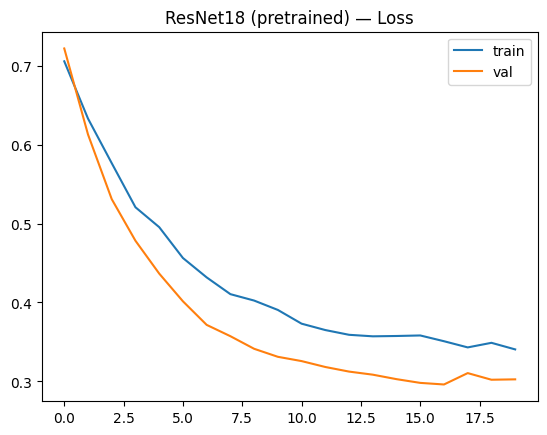

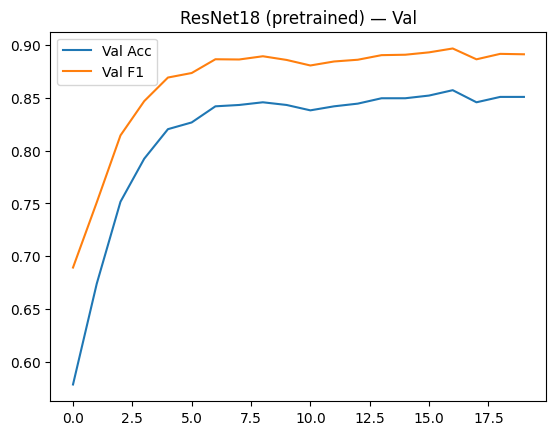

[ResNet18-pretrained @0.5] {'acc': 0.8269, 'precision': 0.8507, 'recall': 0.8769, 'f1': 0.8636, 'auroc': 0.8908, 'thr': 0.5}
[ResNet18-pretrained @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.8908, 'thr': 0.0137}


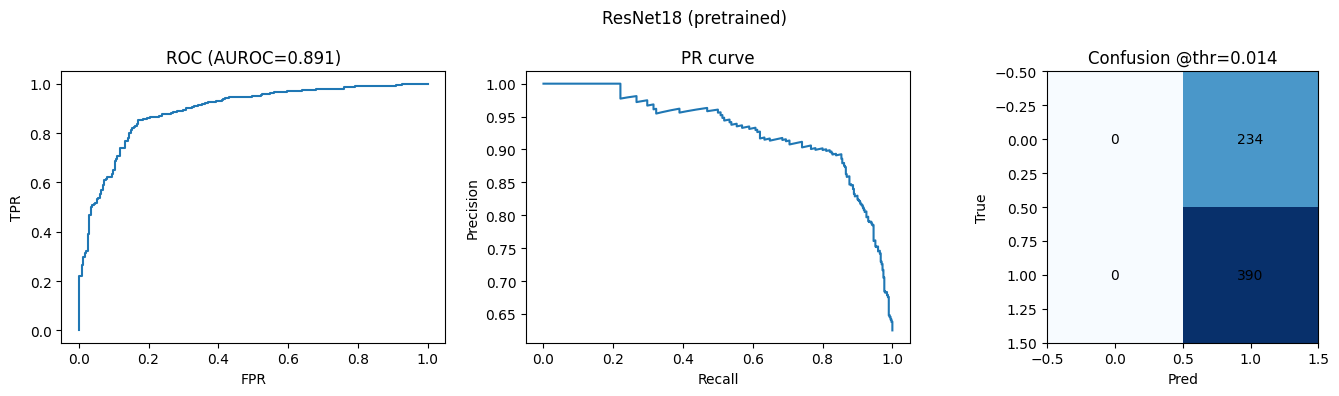

{'summary@0.5': {'acc': 0.8269230769230769,
  'precision': 0.8507462686567164,
  'recall': 0.8769230769230769,
  'f1': 0.8636363636363636,
  'auroc': 0.8908393600701293,
  'thr': 0.5},
 'summary@recall': {'acc': 0.625,
  'precision': 0.625,
  'recall': 1.0,
  'f1': 0.7692307692307693,
  'auroc': 0.8908393600701293,
  'thr': 0.013664280995726585},
 'threshold': 0.013664280995726585,
 'time_sec': 1215.2628297805786,
 'params': 11177538}

In [ ]:
cfg = pretrain_cfg

rn = build_resnet18(in_chans=3, num_classes=2, pretrained=True, conv_stem=False)
t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=cfg.epochs, base_lr=cfg.base_lr, weight_decay=cfg.weight_decay, label_smoothing=0.0,
    use_sam=False, sam_rho=0.05,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=5, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-pretrained"
); rn_time = time.time() - t0

plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 (pretrained) — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 (pretrained) — Val")

va = evaluate(rn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-pretrained @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-pretrained @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (pretrained)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (pretrained)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-B/16-pretrained] epoch 01/20  tr_loss=0.5262  val_loss=0.2882  val_acc=0.8510  val_f1=0.8895  val_auroc=0.9629  (no_improve=0)
[ViT-B/16-pretrained] epoch 02/20  tr_loss=0.4290  val_loss=0.4260  val_acc=0.7389  val_f1=0.7871  val_auroc=0.9620  (no_improve=1)
[ViT-B/16-pretrained] epoch 03/20  tr_loss=0.4052  val_loss=0.2739  val_acc=0.8904  val_f1=0.9220  val_auroc=0.9595  (no_improve=2)
[ViT-B/16-pretrained] epoch 04/20  tr_loss=0.3846  val_loss=0.2572  val_acc=0.8764  val_f1=0.9103  val_auroc=0.9633  (no_improve=0)
[ViT-B/16-pretrained] epoch 05/20  tr_loss=0.3651  val_loss=0.2382  val_acc=0.8994  val_f1=0.9284  val_auroc=0.9720  (no_improve=0)
[ViT-B/16-pretrained] epoch 06/20  tr_loss=0.3629  val_loss=0.2930  val_acc=0.8510  val_f1=0.8891  val_auroc=0.9751  (no_improve=0)
[ViT-B/16-pretrained] epoch 07/20  tr_loss=0.3432  val_loss=0.3543  val_acc=0.8293  val_f1=0.8709  val_auroc=0.9724  (no_improve=1)
[ViT-B/16-pretrained] epoch 08/20  tr_loss=0.3397  val_loss=0.2013  val_acc=

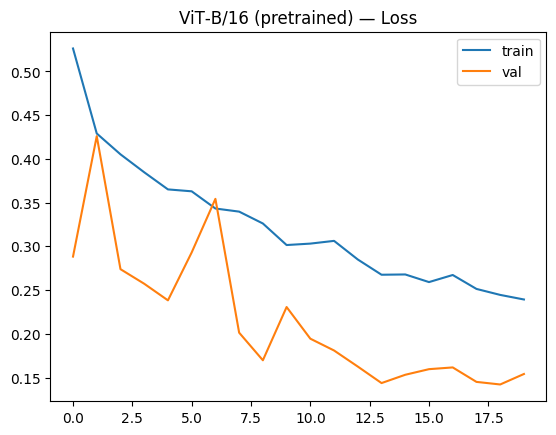

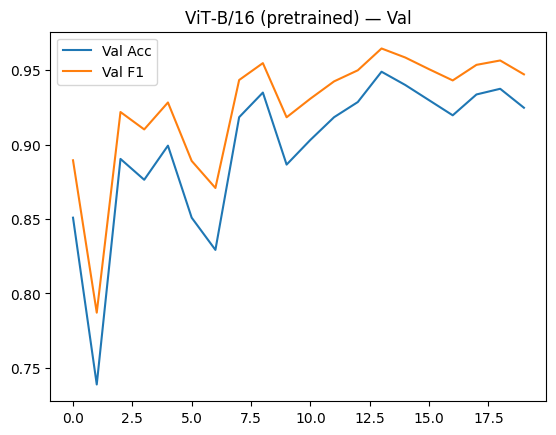

[ViT-B/16-pretrained @0.5] {'acc': 0.8878, 'precision': 0.8941, 'recall': 0.9308, 'f1': 0.9121, 'auroc': 0.9404, 'thr': 0.5}
[ViT-B/16-pretrained @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.9404, 'thr': 0.0011}


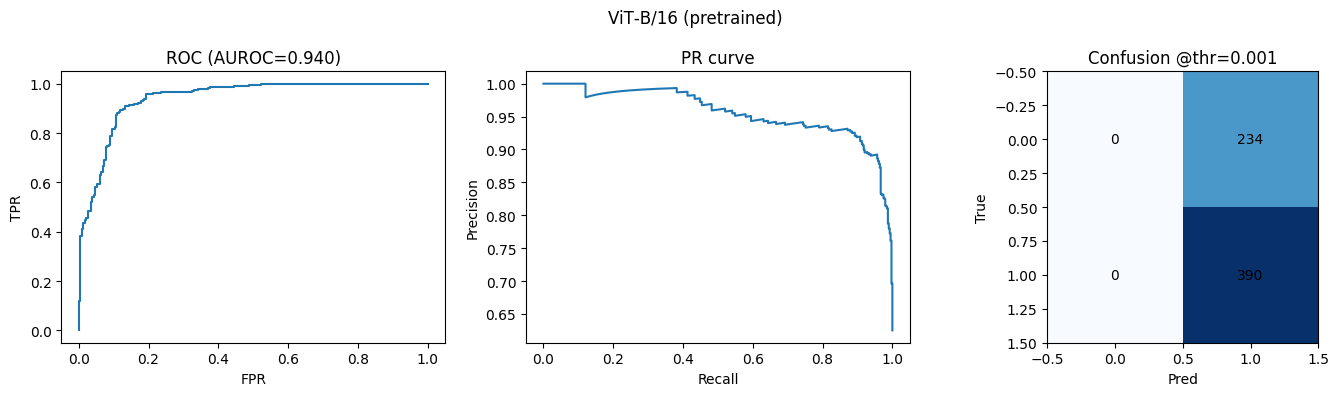

In [ ]:
try:
    vit = build_vit_pretrained(
        num_classes=2, model_name="vit_base_patch16_224",
        pretrained=True, npz_path=pretrain_cfg.vit_npz_path  # falls back to notebooks/weights/ViT-B_16.npz in src if timm unavailable
    )
except Exception as e:
    print("ViT‑B/16 pretrained unavailable (no timm and no .npz). Skipping ViT cell.")
    vit = None

if vit is not None:
    t0 = time.time()
    vit_tr, vit_hist, vit_time = train_model(
        vit, train_loader, val_loader, DEVICE, arch="vit",
        epochs=pretrain_cfg.epochs, base_lr=pretrain_cfg.base_lr, weight_decay=pretrain_cfg.weight_decay, label_smoothing=0.0,
        use_sam=False, sam_rho=0.2,
        use_cosine=pretrain_cfg.use_cosine, warmup_epochs=pretrain_cfg.warmup_epochs, min_lr_mult=pretrain_cfg.min_lr_mult,
        monitor=pretrain_cfg.monitor, patience=pretrain_cfg.patience, clip_grad_norm=pretrain_cfg.clip_grad_norm,
        class_weights=class_weights, llrd=pretrain_cfg.llrd, head_lr_mult=pretrain_cfg.head_lr_mult, use_amp=pretrain_cfg.use_amp,
        tag="ViT-B/16-pretrained"
    ); vit_time = time.time() - t0

    plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT‑B/16 (pretrained) — Loss")
    plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT‑B/16 (pretrained) — Val")

    va = evaluate(vit_tr, val_loader, DEVICE)
    thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], pretrain_cfg.target_recall)
    te = evaluate(vit_tr, test_loader, DEVICE)
    sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
    sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
    print("[ViT-B/16-pretrained @0.5]", {k: round(v,4) for k,v in sum_05.items()})
    print("[ViT-B/16-pretrained @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
    diag_plots("ViT‑B/16 (pretrained)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
    add_result("ViT‑B/16 (pretrained)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [ ]:
import pandas as pd
from src import result_registry as RR

rows=[]
for name, d in RR.items():
    s = d.get("summary@recall", d.get("summary@0.5"))
    if not s: continue
    thr = d.get("threshold", s.get("thr", 0.5))
    rows.append({
        "Model": name,
        "Params (M)": round(d.get("params", 0)/1e6, 2) if d.get("params") else None,
        "Time (min)": round(d.get("time_sec", 0)/60, 2) if d.get("time_sec") else None,
        "Acc": round(s["acc"],4), "Prec": round(s["precision"],4),
        "Recall": round(s["recall"],4), "F1": round(s["f1"],4),
        "AUROC": round(s.get("auroc", float('nan')),4), "Thr": round(thr,3)
    })
df = pd.DataFrame(rows).sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
display(df); print(df.to_string(index=False))


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,ViT‑B/16 (pretrained),85.80,74.00,0.625,0.625,1.0,0.7692,0.9404,0.001
1,ResNet18 (pretrained),11.18,20.25,0.625,0.625,1.0,0.7692,0.8908,0.014


                Model  Params (M)  Time (min)   Acc  Prec  Recall     F1  AUROC   Thr
ViT‑B/16 (pretrained)       85.80       74.00 0.625 0.625     1.0 0.7692 0.9404 0.001
ResNet18 (pretrained)       11.18       20.25 0.625 0.625     1.0 0.7692 0.8908 0.014
